In [1]:
import time
from edu1sces.model import KondoLatticeModel
from edu1sces.solver import solve, SolverParameters
import matplotlib.pyplot as plt

In [2]:
N = 10  # サイト数
num_electrons = 4  # 電子数
total_sz = 0
J_kondo = 1.0  # 近藤結合

model = KondoLatticeModel(
    spins={i: 0.5 for i in range(N)},
    hopping={(i, i + 1): -1.0 for i in range(N - 1)},
    kondo_xy={i: J_kondo for i in range(N)},
    kondo_z={i: J_kondo for i in range(N)},
)
params = SolverParameters(output_log=True, num_threads=6)
result = solve(model, num_electrons=num_electrons, total_sz=total_sz, params=params)
print(f"Energy: {result.energy}")

Building basis...
Done in 0.7s (6 threads)
Building Hamiltonian...
Done in 4.5s (6 threads)
Diagonalizing Hamiltonian...
Done in 17.7s (6 threads)                         
Improving eigenvector...
Done in 6.3s (6 threads)                          
Energy: -7.908463740640349


In [3]:
Sz_cfs = []
time_start = time.perf_counter()
for i in range(N):
    Sz_0 = model.make_local_op_l_sz(0)
    Sz_i = model.make_local_op_l_sz(i)
    Sz_cfs.append(result.correlation_function(Sz_0, 0, Sz_i, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 1.737234874999558 sec


In [4]:
Szc_cfs = []
time_start = time.perf_counter()
for i in range(N):
    Sz_0 = model.make_local_op_c_sz(0)
    Sz_i = model.make_local_op_c_sz(i)
    Szc_cfs.append(result.correlation_function(Sz_0, 0, Sz_i, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 0.9793809999973746 sec


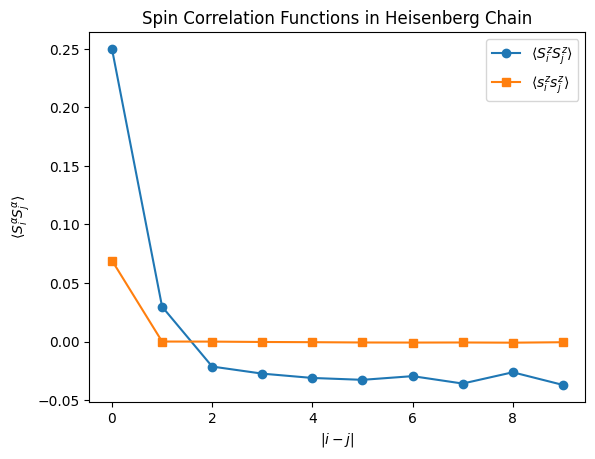

In [5]:
plt.plot(range(N), Sz_cfs, marker="o", label=r"$\langle S_i^z S_j^z \rangle$")
plt.plot(range(N), Szc_cfs, marker="s", label=r"$\langle s_i^z s_j^z \rangle$")
plt.xlabel(r"$|i-j|$")
plt.ylabel(r"$\langle S_i^\alpha S_j^\alpha \rangle$")
plt.title("Spin Correlation Functions in Heisenberg Chain")
plt.legend()